In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Bootstrap

In [ ]:
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from itertools import combinations

def bootstrap_auc_diff(y_true, scores_a, scores_b,
                       n_iterations=2000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_iterations)
    n = 1000
    for i in range(n_iterations):
        idx = rng.choice(n, size=n, replace=True)
        a = roc_auc_score(y_true[idx], scores_a[idx])
        b = roc_auc_score(y_true[idx], scores_b[idx])
        diffs[i] = a - b
    mean_diff = diffs.mean()
    lower = np.percentile(diffs, (100 - ci) / 2)
    upper = np.percentile(diffs, 100 - (100 - ci) / 2)
    p_value = np.mean(np.abs(diffs) >= abs(mean_diff))
    return mean_diff, (lower, upper), p_value, diffs

def compare_all_pairs(y_true, scores, n_iterations=2000, ci=95):
    records = []
    for m1, m2 in combinations(scores.keys(), 2):
        mean_diff, (low, high), p, diffs = bootstrap_auc_diff(
            y_true, scores[m1], scores[m2],
            n_iterations=n_iterations, ci=ci
        )
        records.append({
            'Model A': m1,
            'Model B': m2,
            'Mean ΔAUC': mean_diff,
            f'{ci}% CI': f'{low:.3f}, {high:.3f}',
            'p-value': p
        })
    return pd.DataFrame(records).sort_values('p-value').reset_index(drop=True)

n_steps = 14
y_true_pattern = "../../../DATA/MDR/s{split}/y_test_tensor_robustNorm.csv"
pkl_paths = {
    "GRU":           "POST-HOC/Results_GRU/split_1/y_pred_split_1.pkl",
    "LSTM":          "POST-HOC/Results_LSTM/split_1/y_pred_split_1.pkl",
    "Vanilla RNN":   "POST-HOC/Results_Vanilla/split_1/y_pred_split_1.pkl",
    "GRU Had. Att.":"INTRINSIC/Results_GRU_Had/split_1/y_pred_split_1.pkl",
    "LSTM Had. Att.":"INTRINSIC/Results_LSTM_Had/split_1/y_pred_split_1.pkl",
    "Vanilla RNN Had. Att.":"INTRINSIC/Results_Vanilla_Had/split_1/y_pred_split_1.pkl",
    "Transformer":   "POST-HOC/Results_transformer/split_1/y_pred_split_1.pkl",
    "Transformer Had. Att.":"INTRINSIC/Results_transformer_Had/split_1/y_pred_split_1.pkl",
}

y_list = []
scores_acc = {m: [] for m in pkl_paths}

for split in [1, 2, 3]:

    df = pd.read_csv(y_true_pattern.format(split=split))
    flat_true = df['individualMRGerm'].values 
    mask = (flat_true != 666)
    y_list.append(flat_true[mask].astype(int))
    
    for m, tmpl in pkl_paths.items():
        pfile = (tmpl.replace("split_1", f"split_{split}").replace("_1.pkl", f"_{split}.pkl"))
        
        print(pfile)
        pred_seq = pickle.load(open(pfile, "rb"))
        arr = np.asarray(pred_seq)
        # arr shape: (n_samples, T, channels)
        flat = arr.reshape(-1, arr.shape[-1]) 

        max_t = flat.max(axis=1)              
        scores_acc[m].append(max_t[mask])


y_all = np.concatenate(y_list)
scores_all = {m: np.concatenate(lst) for m, lst in scores_acc.items()}

print(y_all.shape)
df_results = compare_all_pairs(y_all, scores_all,
                               n_iterations=2000, ci=95)

print(df_results.to_string(index=False))

POST-HOC/Results_GRU/split_1/y_pred_split_1.pkl
POST-HOC/Results_LSTM/split_1/y_pred_split_1.pkl
POST-HOC/Results_Vanilla/split_1/y_pred_split_1.pkl
INTRINSIC/Results_GRU_Had/split_1/y_pred_split_1.pkl
INTRINSIC/Results_LSTM_Had/split_1/y_pred_split_1.pkl
INTRINSIC/Results_Vanilla_Had/split_1/y_pred_split_1.pkl
POST-HOC/Results_transformer/split_1/y_pred_split_1.pkl
INTRINSIC/Results_transformer_Had/split_1/y_pred_split_1.pkl
POST-HOC/Results_GRU/split_2/y_pred_split_2.pkl
POST-HOC/Results_LSTM/split_2/y_pred_split_2.pkl
POST-HOC/Results_Vanilla/split_2/y_pred_split_2.pkl
INTRINSIC/Results_GRU_Had/split_2/y_pred_split_2.pkl
INTRINSIC/Results_LSTM_Had/split_2/y_pred_split_2.pkl
INTRINSIC/Results_Vanilla_Had/split_2/y_pred_split_2.pkl
POST-HOC/Results_transformer/split_2/y_pred_split_2.pkl
INTRINSIC/Results_transformer_Had/split_2/y_pred_split_2.pkl
POST-HOC/Results_GRU/split_3/y_pred_split_3.pkl
POST-HOC/Results_LSTM/split_3/y_pred_split_3.pkl
POST-HOC/Results_Vanilla/split_3/y_pred_spl

In [ ]:
labels = []
means  = []
lows   = []
highs  = []
sig    = []  

diffs_dict = {}
for m1, m2 in combinations(scores_all.keys(), 2):
    mean_diff, (low, high), p, diffs = bootstrap_auc_diff(
        y_all, scores_all[m1], scores_all[m2],
        n_iterations=2000, ci=95, seed=42
    )
    label = f"{m1} – {m2}"
    labels.append(label)
    means.append(mean_diff)
    lows.append(mean_diff - low)    
    highs.append(high - mean_diff)  
    sig.append((low > 0) or (high < 0))
    diffs_dict[label] = diffs

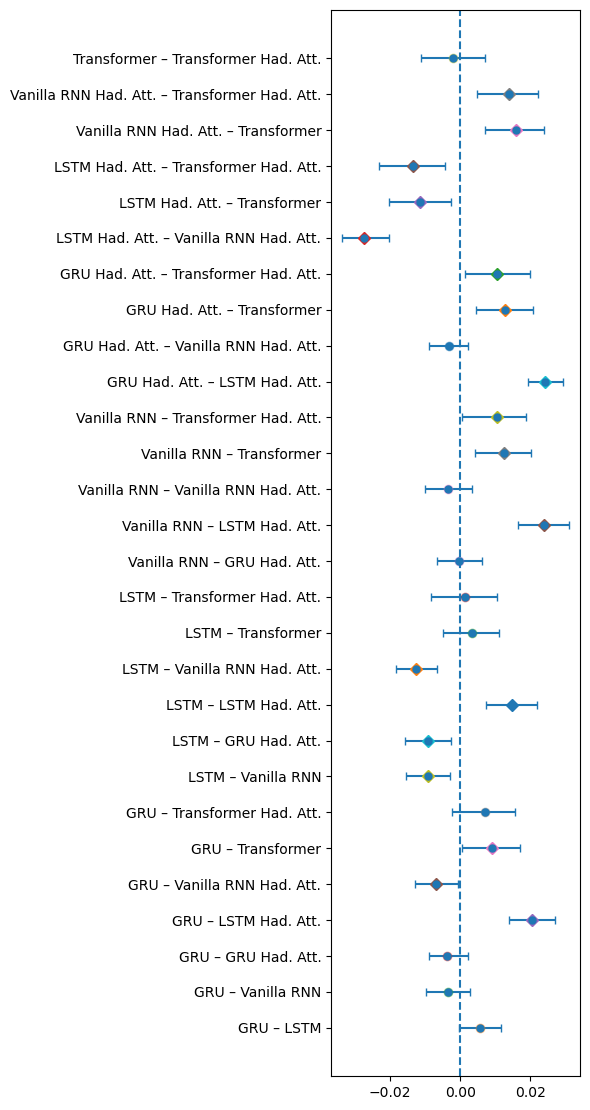

In [4]:
# 3) Plot forest plot
fig, ax = plt.subplots(figsize=(6, len(labels)*0.4))
y_pos = np.arange(len(labels))

ax.errorbar(means, y_pos, xerr=[lows, highs],
            fmt='o',  
            markersize=5,
            capsize=3)
for i, s in enumerate(sig):
    if s:
        ax.plot(means[i], y_pos[i], marker='D', markersize=6)  
    else:
        ax.plot(means[i], y_pos[i], marker='o', markersize=6, alpha=0.5)

ax.axvline(0, linestyle='--')      
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
plt.tight_layout()
plt.savefig('./Figures/forest_plot_MDR.pdf')
plt.show()

## 2.Permutation

In [5]:
paths = {
    'GRU':                     "POST-HOC/Results_GRU/metrics_GRU.csv",
    'LSTM':                    "POST-HOC/Results_LSTM/metrics_LSTM.csv",
    'Vanilla RNN':             "POST-HOC/Results_Vanilla/metrics_Vanilla.csv",
    'GRU Had. Att.':           "INTRINSIC/Results_GRU_Had/metrics_GRU_Had.csv",
    'LSTM Had. Att.':          "INTRINSIC/Results_LSTM_Had/metrics_LSTM_Had.csv",
    'Vanilla RNN Had. Att.':   "INTRINSIC/Results_Vanilla_Had/metrics_Vanilla_Had.csv",
    'Transformer':             "POST-HOC/Results_transformer/metrics_transformer.csv",
    'Transformer Had. Att.':   "INTRINSIC/Results_transformer_Had/metrics_transformer_Had.csv",
}

roc = {}
n_splits = 3
n_horizons = 14

for model, path in paths.items():
    df = pd.read_csv(path)
    if 'Time Step' in df.columns:
        df = df.sort_values('Time Step').reset_index(drop=True)
    arr = df['ROC AUC'].values
    assert arr.size == n_splits * n_horizons, \
        f"{model}: esperado {n_splits*n_horizons} valores, hay {arr.size}"
    roc[model] = arr.reshape(n_splits, n_horizons)


In [6]:
import numpy as np
import itertools
import pandas as pd

def exhaustive_count_mean(D, two_sided=True, n_iters=4):
    n_splits = D.shape[0]
    t_obs = D.ravel().mean()
    count = 0
    total = 0

    for signs in itertools.product([-1, 1], repeat=n_splits):
        if total >= n_iters:
            break
        signs = np.array(signs)
        t_s = (D * signs[:, None]).mean()
        if two_sided:
            if abs(t_s) >= abs(t_obs):
                count += 1
        else:
            if t_s >= t_obs:
                count += 1
        total += 1

    return t_obs, count, total


results = []
for A, B in itertools.combinations(roc.keys(), 2):
    D = roc[A] - roc[B]

    t_m, cnt_m, tot_m = exhaustive_count_mean(D, two_sided=False, n_iters=8)
    p_m = (cnt_m + 1) / (tot_m + 1)


    results.append({
        'Model A': A,
        'Model B': B,
        'T_obs_mean': t_m,
        'Count_mean': cnt_m,
        'Total_mean': tot_m,
        'P_one_sided_mean': p_m,
    })

res_df = pd.DataFrame(results)
print(res_df)


                  Model A                Model B  T_obs_mean  Count_mean  \
0                     GRU                   LSTM    0.009659           3   
1                     GRU            Vanilla RNN   -0.003131           8   
2                     GRU          GRU Had. Att.   -0.018621           8   
3                     GRU         LSTM Had. Att.   -0.013100           8   
4                     GRU  Vanilla RNN Had. Att.   -0.008698           8   
5                     GRU            Transformer    0.005009           2   
6                     GRU  Transformer Had. Att.    0.013014           1   
7                    LSTM            Vanilla RNN   -0.012790           7   
8                    LSTM          GRU Had. Att.   -0.028281           8   
9                    LSTM         LSTM Had. Att.   -0.022759           7   
10                   LSTM  Vanilla RNN Had. Att.   -0.018357           7   
11                   LSTM            Transformer   -0.004650           6   
12          

In [7]:
import numpy as np
import itertools
import pandas as pd

results_subsets = []
models = list(roc.keys())

for A in models:
    others = [m for m in models if m != A]
    for r in range(1, len(others)+1):
        for subset in itertools.combinations(others, r):
            arrs = [roc[m] for m in subset]
            mean_subset = np.mean(np.stack(arrs, axis=0), axis=0)
            
            D = roc[A] - mean_subset

            t_m, cnt_m, tot_m = exhaustive_count_mean(D, two_sided=False, n_iters=8)
            p_m = (cnt_m + 1) / (tot_m + 1)

            results_subsets.append({
                'Model A': A,
                'Subset': "+".join(subset),
                'Size': len(subset),
                'Count_mean': cnt_m,
                'Total_mean': tot_m,
                'T_obs_mean': t_m,
                'P_one_sided_mean': p_m,
            })

df_subsets = pd.DataFrame(results_subsets)
df_subsets = df_subsets.sort_values(['Model A','Size','P_one_sided_mean']).reset_index(drop=True)

print(df_subsets.to_string(index=False))


              Model A                                                                                                Subset  Size  Count_mean  Total_mean  T_obs_mean  P_one_sided_mean
                  GRU                                                                                 Transformer Had. Att.     1           1           8    0.013014          0.222222
                  GRU                                                                                           Transformer     1           2           8    0.005009          0.333333
                  GRU                                                                                                  LSTM     1           3           8    0.009659          0.444444
                  GRU                                                                                           Vanilla RNN     1           8           8   -0.003131          1.000000
                  GRU                                                           

/tmp/ipykernel_402275/2456503507.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  orig = cm.get_cmap('viridis_r', 256)              # viridis reversed


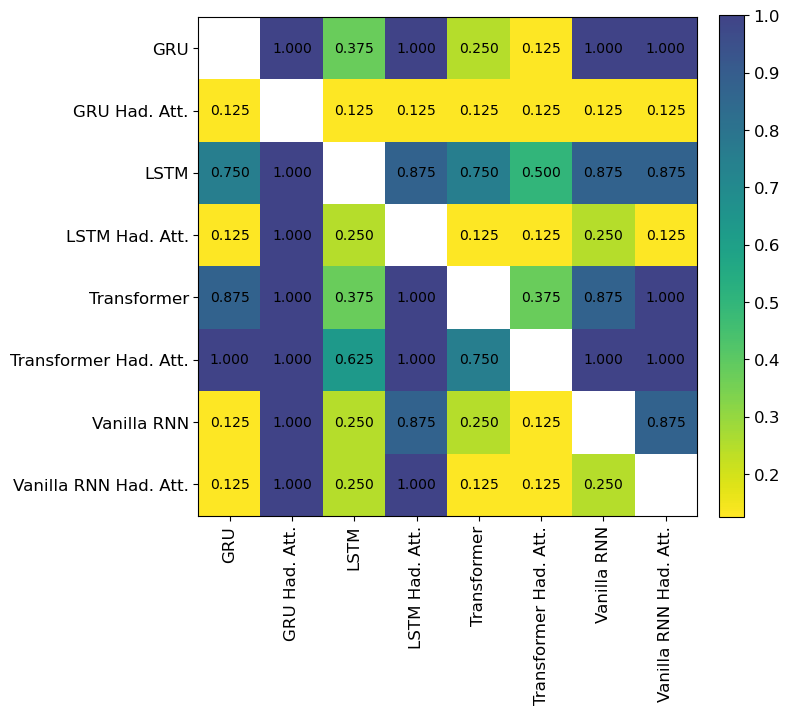

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

pair_df = df_subsets[df_subsets['Size'] == 1]
models = sorted(roc.keys())
count_matrix = np.zeros((len(models), len(models)), dtype=int)

for _, row in pair_df.iterrows():
    i = models.index(row['Model A'])
    j = models.index(row['Subset'])
    count_matrix[i, j] = int(row['Count_mean'])
scaled_matrix = count_matrix / 8.0

mask = np.eye(len(models), dtype=bool)
masked_matrix = np.ma.masked_where(mask, scaled_matrix)


orig = cm.get_cmap('viridis_r', 256)              # viridis reversed
new_colors = orig(np.linspace(0.0, 0.8, 256))     
viridis_cut = ListedColormap(new_colors)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(masked_matrix,
               aspect='equal',
               cmap=viridis_cut)   

ax.set_xticks(np.arange(len(models)))
ax.set_yticks(np.arange(len(models)))
ax.set_xticklabels(models, rotation=90, fontsize=12)
ax.set_yticklabels(models, fontsize=12)

for i in range(len(models)):
    for j in range(len(models)):
        if i == j:
            continue
        ax.text(j, i,
                f"{scaled_matrix[i, j]:.3f}",
                ha='center', va='center',
                fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('./Figures/permutation_MDR.pdf')
plt.show()


# GRU

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df_gru = pd.read_csv(f"POST-HOC/Results_GRU/metrics_GRU.csv")
df_gru_had = pd.read_csv(f"INTRINSIC/Results_GRU_Had/metrics_GRU_Had.csv")

# Initialize storage for summary
time_steps = df_gru['Time Step'].unique()

gru_means = []
gru_stds = []
gru_had_means = []
gru_had_stds = []

# Storage for Recall and Specificity
gru_recall_means = []
gru_recall_stds = []
gru_specificity_means = []
gru_specificity_stds = []

gru_had_recall_means = []
gru_had_recall_stds = []
gru_had_specificity_means = []
gru_had_specificity_stds = []

# Compute mean and std for each time step
for t in time_steps:
    # For GRU
    gru_roc = df_gru[df_gru['Time Step'] == t]['ROC AUC']
    gru_recall = df_gru[df_gru['Time Step'] == t]['Recall']
    gru_specificity = df_gru[df_gru['Time Step'] == t]['Specificity']
    
    # For GRU + Attention
    gru_had_roc = df_gru_had[df_gru_had['Time Step'] == t]['ROC AUC']
    gru_had_recall = df_gru_had[df_gru_had['Time Step'] == t]['Recall']
    gru_had_specificity = df_gru_had[df_gru_had['Time Step'] == t]['Specificity']
    
    # Store means and stds for GRU
    gru_means.append(gru_roc.mean())
    gru_stds.append(gru_roc.std())
    gru_recall_means.append(gru_recall.mean())
    gru_recall_stds.append(gru_recall.std())
    gru_specificity_means.append(gru_specificity.mean())
    gru_specificity_stds.append(gru_specificity.std())
    
    # Store means and stds for GRU + Attention
    gru_had_means.append(gru_had_roc.mean())
    gru_had_stds.append(gru_had_roc.std())
    gru_had_recall_means.append(gru_had_recall.mean())
    gru_had_recall_stds.append(gru_had_recall.std())
    gru_had_specificity_means.append(gru_had_specificity.mean())
    gru_had_specificity_stds.append(gru_had_specificity.std())

# Convert lists to numpy arrays
gru_means = np.array(gru_means)
gru_stds = np.array(gru_stds)
gru_had_means = np.array(gru_had_means)
gru_had_stds = np.array(gru_had_stds)

gru_recall_means = np.array(gru_recall_means)
gru_recall_stds = np.array(gru_recall_stds)
gru_specificity_means = np.array(gru_specificity_means)
gru_specificity_stds = np.array(gru_specificity_stds)

gru_had_recall_means = np.array(gru_had_recall_means)
gru_had_recall_stds = np.array(gru_had_recall_stds)
gru_had_specificity_means = np.array(gru_had_specificity_means)
gru_had_specificity_stds = np.array(gru_had_specificity_stds)

# Calculate average and mean std over all time steps for ROC AUC, Recall, Specificity
average_gru_roc_auc = np.mean(gru_means)
mean_gru_roc_std = np.mean(gru_stds)

average_gru_had_roc_auc = np.mean(gru_had_means)
mean_gru_had_roc_std = np.mean(gru_had_stds)

average_gru_recall = np.mean(gru_recall_means)
mean_gru_recall_std = np.mean(gru_recall_stds)

average_gru_specificity = np.mean(gru_specificity_means)
mean_gru_specificity_std = np.mean(gru_specificity_stds)

average_gru_had_recall = np.mean(gru_had_recall_means)
mean_gru_had_recall_std = np.mean(gru_had_recall_stds)

average_gru_had_specificity = np.mean(gru_had_specificity_means)
mean_gru_had_specificity_std = np.mean(gru_had_specificity_stds)


# LSTM


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df_lstm = pd.read_csv(f"POST-HOC/Results_LSTM/metrics_LSTM.csv")
df_lstm_had = pd.read_csv(f"INTRINSIC/Results_LSTM_Had/metrics_LSTM_Had.csv")

# Initialize storage for summary
time_steps = df_lstm['Time Step'].unique()

lstm_means = []
lstm_stds = []
lstm_had_means = []
lstm_had_stds = []

# Storage for Recall and Specificity
lstm_recall_means = []
lstm_recall_stds = []
lstm_specificity_means = []
lstm_specificity_stds = []

lstm_had_recall_means = []
lstm_had_recall_stds = []
lstm_had_specificity_means = []
lstm_had_specificity_stds = []

# Compute mean and std for each time step
for t in time_steps:
    # For LSTM
    lstm_roc = df_lstm[df_lstm['Time Step'] == t]['ROC AUC']
    lstm_recall = df_lstm[df_lstm['Time Step'] == t]['Recall']
    lstm_specificity = df_lstm[df_lstm['Time Step'] == t]['Specificity']
    
    # For LSTM + Attention
    lstm_had_roc = df_lstm_had[df_lstm_had['Time Step'] == t]['ROC AUC']
    lstm_had_recall = df_lstm_had[df_lstm_had['Time Step'] == t]['Recall']
    lstm_had_specificity = df_lstm_had[df_lstm_had['Time Step'] == t]['Specificity']
    
    # Store means and stds for LSTM
    lstm_means.append(lstm_roc.mean())
    lstm_stds.append(lstm_roc.std())
    lstm_recall_means.append(lstm_recall.mean())
    lstm_recall_stds.append(lstm_recall.std())
    lstm_specificity_means.append(lstm_specificity.mean())
    lstm_specificity_stds.append(lstm_specificity.std())
    
    # Store means and stds for LSTM + Attention
    lstm_had_means.append(lstm_had_roc.mean())
    lstm_had_stds.append(lstm_had_roc.std())
    lstm_had_recall_means.append(lstm_had_recall.mean())
    lstm_had_recall_stds.append(lstm_had_recall.std())
    lstm_had_specificity_means.append(lstm_had_specificity.mean())
    lstm_had_specificity_stds.append(lstm_had_specificity.std())

# Convert lists to numpy arrays
lstm_means = np.array(lstm_means)
lstm_stds = np.array(lstm_stds)
lstm_had_means = np.array(lstm_had_means)
lstm_had_stds = np.array(lstm_had_stds)

lstm_recall_means = np.array(lstm_recall_means)
lstm_recall_stds = np.array(lstm_recall_stds)
lstm_specificity_means = np.array(lstm_specificity_means)
lstm_specificity_stds = np.array(lstm_specificity_stds)

lstm_had_recall_means = np.array(lstm_had_recall_means)
lstm_had_recall_stds = np.array(lstm_had_recall_stds)
lstm_had_specificity_means = np.array(lstm_had_specificity_means)
lstm_had_specificity_stds = np.array(lstm_had_specificity_stds)

# Calculate average and mean std over all time steps for ROC AUC, Recall, Specificity
average_lstm_roc_auc = np.mean(lstm_means)
mean_lstm_roc_std = np.mean(lstm_stds)

average_lstm_had_roc_auc = np.mean(lstm_had_means)
mean_lstm_had_roc_std = np.mean(lstm_had_stds)

average_lstm_recall = np.mean(lstm_recall_means)
mean_lstm_recall_std = np.mean(lstm_recall_stds)

average_lstm_specificity = np.mean(lstm_specificity_means)
mean_lstm_specificity_std = np.mean(lstm_specificity_stds)

average_lstm_had_recall = np.mean(lstm_had_recall_means)
mean_lstm_had_recall_std = np.mean(lstm_had_recall_stds)

average_lstm_had_specificity = np.mean(lstm_had_specificity_means)
mean_lstm_had_specificity_std = np.mean(lstm_had_specificity_stds)


# Vanilla

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df_vanilla = pd.read_csv(f"POST-HOC/Results_Vanilla/metrics_Vanilla.csv")
df_vanilla_had = pd.read_csv(f"INTRINSIC/Results_Vanilla_Had/metrics_Vanilla_Had.csv")

# Initialize storage for summary
time_steps = df_vanilla['Time Step'].unique()

vanilla_means = []
vanilla_stds = []
vanilla_had_means = []
vanilla_had_stds = []

# Storage for Recall and Specificity
vanilla_recall_means = []
vanilla_recall_stds = []
vanilla_specificity_means = []
vanilla_specificity_stds = []

vanilla_had_recall_means = []
vanilla_had_recall_stds = []
vanilla_had_specificity_means = []
vanilla_had_specificity_stds = []

# Compute mean and std for each time step
for t in time_steps:
    # For Vanilla GRU
    vanilla_roc = df_vanilla[df_vanilla['Time Step'] == t]['ROC AUC']
    vanilla_recall = df_vanilla[df_vanilla['Time Step'] == t]['Recall']
    vanilla_specificity = df_vanilla[df_vanilla['Time Step'] == t]['Specificity']
    
    # For Vanilla GRU + Attention
    vanilla_had_roc = df_vanilla_had[df_vanilla_had['Time Step'] == t]['ROC AUC']
    vanilla_had_recall = df_vanilla_had[df_vanilla_had['Time Step'] == t]['Recall']
    vanilla_had_specificity = df_vanilla_had[df_vanilla_had['Time Step'] == t]['Specificity']
    
    # Store means and stds for Vanilla GRU
    vanilla_means.append(vanilla_roc.mean())
    vanilla_stds.append(vanilla_roc.std())
    vanilla_recall_means.append(vanilla_recall.mean())
    vanilla_recall_stds.append(vanilla_recall.std())
    vanilla_specificity_means.append(vanilla_specificity.mean())
    vanilla_specificity_stds.append(vanilla_specificity.std())
    
    # Store means and stds for Vanilla GRU + Attention
    vanilla_had_means.append(vanilla_had_roc.mean())
    vanilla_had_stds.append(vanilla_had_roc.std())
    vanilla_had_recall_means.append(vanilla_had_recall.mean())
    vanilla_had_recall_stds.append(vanilla_had_recall.std())
    vanilla_had_specificity_means.append(vanilla_had_specificity.mean())
    vanilla_had_specificity_stds.append(vanilla_had_specificity.std())

# Convert lists to numpy arrays
vanilla_means = np.array(vanilla_means)
vanilla_stds = np.array(vanilla_stds)
vanilla_had_means = np.array(vanilla_had_means)
vanilla_had_stds = np.array(vanilla_had_stds)

vanilla_recall_means = np.array(vanilla_recall_means)
vanilla_recall_stds = np.array(vanilla_recall_stds)
vanilla_specificity_means = np.array(vanilla_specificity_means)
vanilla_specificity_stds = np.array(vanilla_specificity_stds)

vanilla_had_recall_means = np.array(vanilla_had_recall_means)
vanilla_had_recall_stds = np.array(vanilla_had_recall_stds)
vanilla_had_specificity_means = np.array(vanilla_had_specificity_means)
vanilla_had_specificity_stds = np.array(vanilla_had_specificity_stds)

# Calculate average and mean std over all time steps for ROC AUC, Recall, Specificity
average_vanilla_roc_auc = np.mean(vanilla_means)
mean_vanilla_roc_std = np.mean(vanilla_stds)

average_vanilla_had_roc_auc = np.mean(vanilla_had_means)
mean_vanilla_had_roc_std = np.mean(vanilla_had_stds)

average_vanilla_recall = np.mean(vanilla_recall_means)
mean_vanilla_recall_std = np.mean(vanilla_recall_stds)

average_vanilla_specificity = np.mean(vanilla_specificity_means)
mean_vanilla_specificity_std = np.mean(vanilla_specificity_stds)

average_vanilla_had_recall = np.mean(vanilla_had_recall_means)
mean_vanilla_had_recall_std = np.mean(vanilla_had_recall_stds)

average_vanilla_had_specificity = np.mean(vanilla_had_specificity_means)
mean_vanilla_had_specificity_std = np.mean(vanilla_had_specificity_stds)

## Transformer

In [12]:
import pandas as pd
import numpy as np

df_trans = pd.read_csv("POST-HOC/Results_transformer/metrics_transformer.csv")
df_trans_had = pd.read_csv("INTRINSIC/Results_transformer_Had/metrics_transformer_Had.csv")

time_steps = df_trans['Time Step'].unique()

trans_means = []
trans_stds = []
trans_had_means = []
trans_had_stds = []

trans_recall_means = []
trans_recall_stds = []
trans_specificity_means = []
trans_specificity_stds = []

trans_had_recall_means = []
trans_had_recall_stds = []
trans_had_specificity_means = []
trans_had_specificity_stds = []

for t in time_steps:
    # For Transformer
    trans_roc = df_trans[df_trans['Time Step'] == t]['ROC AUC']
    trans_recall = df_trans[df_trans['Time Step'] == t]['Recall']
    trans_specificity = df_trans[df_trans['Time Step'] == t]['Specificity']

    # For Transformer + Attention (Hadamard)
    trans_had_roc = df_trans_had[df_trans_had['Time Step'] == t]['ROC AUC']
    trans_had_recall = df_trans_had[df_trans_had['Time Step'] == t]['Recall']
    trans_had_specificity = df_trans_had[df_trans_had['Time Step'] == t]['Specificity']

    # Store means and stds for Transformer
    trans_means.append(trans_roc.mean())
    trans_stds.append(trans_roc.std())
    trans_recall_means.append(trans_recall.mean())
    trans_recall_stds.append(trans_recall.std())
    trans_specificity_means.append(trans_specificity.mean())
    trans_specificity_stds.append(trans_specificity.std())

    # Store means and stds for Transformer + Attention
    trans_had_means.append(trans_had_roc.mean())
    trans_had_stds.append(trans_had_roc.std())
    trans_had_recall_means.append(trans_had_recall.mean())
    trans_had_recall_stds.append(trans_had_recall.std())
    trans_had_specificity_means.append(trans_had_specificity.mean())
    trans_had_specificity_stds.append(trans_had_specificity.std())

# Convert lists to numpy arrays
trans_means = np.array(trans_means)
trans_stds = np.array(trans_stds)
trans_had_means = np.array(trans_had_means)
trans_had_stds = np.array(trans_had_stds)

trans_recall_means = np.array(trans_recall_means)
trans_recall_stds = np.array(trans_recall_stds)
trans_specificity_means = np.array(trans_specificity_means)
trans_specificity_stds = np.array(trans_specificity_stds)

trans_had_recall_means = np.array(trans_had_recall_means)
trans_had_recall_stds = np.array(trans_had_recall_stds)
trans_had_specificity_means = np.array(trans_had_specificity_means)
trans_had_specificity_stds = np.array(trans_had_specificity_stds)

# Calculate overall averages and mean stds across all time steps
average_trans_roc_auc = np.mean(trans_means)
mean_trans_roc_std = np.mean(trans_stds)

average_trans_had_roc_auc = np.mean(trans_had_means)
mean_trans_had_roc_std = np.mean(trans_had_stds)

average_trans_recall = np.mean(trans_recall_means)
mean_trans_recall_std = np.mean(trans_recall_stds)

average_trans_specificity = np.mean(trans_specificity_means)
mean_trans_specificity_std = np.mean(trans_specificity_stds)

average_trans_had_recall = np.mean(trans_had_recall_means)
mean_trans_had_recall_std = np.mean(trans_had_recall_stds)

average_trans_had_specificity = np.mean(trans_had_specificity_means)
mean_trans_had_specificity_std = np.mean(trans_had_specificity_stds)

In [13]:
def process_df(df, method_name):
    # Group by Time Step and calculate mean and standard deviation
    summary_df = df.groupby('Time Step')['ROC AUC'].agg(['mean', 'std']).reset_index()
    summary_df['Method'] = method_name
    return summary_df

In [14]:
data = {
    "Model": [
        "GRU", "GRU + Attention",
        "LSTM", "LSTM + Attention",
        "Vanilla RNN", "Vanilla RNN + Attention",
        "Transformer", "Transformer + Attention"
    ],
    "ROC AUC": [
        average_gru_roc_auc, average_gru_had_roc_auc,
        average_lstm_roc_auc, average_lstm_had_roc_auc,
        average_vanilla_roc_auc, average_vanilla_had_roc_auc,
        average_trans_roc_auc, average_trans_had_roc_auc
    ],
    "Recall": [
        average_gru_recall, average_gru_had_recall,
        average_lstm_recall, average_lstm_had_recall,
        average_vanilla_recall, average_vanilla_had_recall,
        average_trans_recall, average_trans_had_recall
    ],
    "Specificity": [
        average_gru_specificity, average_gru_had_specificity,
        average_lstm_specificity, average_lstm_had_specificity,
        average_vanilla_specificity, average_vanilla_had_specificity,
        average_trans_specificity, average_trans_had_specificity
    ],
    "ROC AUC STD": [
        mean_gru_roc_std, mean_gru_had_roc_std,
        mean_lstm_roc_std, mean_lstm_had_roc_std,
        mean_vanilla_roc_std, mean_vanilla_had_roc_std,
        mean_trans_roc_std, mean_trans_had_roc_std
    ],
    "Recall STD": [
        mean_gru_recall_std, mean_gru_had_recall_std,
        mean_lstm_recall_std, mean_lstm_had_recall_std,
        mean_vanilla_recall_std, mean_vanilla_had_recall_std,
        mean_trans_recall_std, mean_trans_had_recall_std
    ],
    "Specificity STD": [
        mean_gru_specificity_std, mean_gru_had_specificity_std,
        mean_lstm_specificity_std, mean_lstm_had_specificity_std,
        mean_vanilla_specificity_std, mean_vanilla_had_specificity_std,
        mean_trans_specificity_std, mean_trans_had_specificity_std
    ],
}

data['ROC AUC ± STD'] = [
    f"{mu:.4f} ± {sigma:.4f}"
    for mu, sigma in zip(data['ROC AUC'], data['ROC AUC STD'])
]
data['Recall ± STD'] = [
    f"{mu:.4f} ± {sigma:.4f}"
    for mu, sigma in zip(data['Recall'], data['Recall STD'])
]
data['Specificity ± STD'] = [
    f"{mu:.4f} ± {sigma:.4f}"
    for mu, sigma in zip(data['Specificity'], data['Specificity STD'])
]

df = pd.DataFrame(data)
df = df.drop(columns=[
    "ROC AUC", "Recall", "Specificity",
    "ROC AUC STD", "Recall STD", "Specificity STD"
])

print(df.to_string(index=False))

                  Model   ROC AUC ± STD    Recall ± STD Specificity ± STD
                    GRU 0.7648 ± 0.0219 0.6943 ± 0.0310   0.7073 ± 0.0201
        GRU + Attention 0.7834 ± 0.0231 0.6952 ± 0.0408   0.7525 ± 0.0322
                   LSTM 0.7552 ± 0.0379 0.6668 ± 0.0864   0.7107 ± 0.0604
       LSTM + Attention 0.7779 ± 0.0203 0.6352 ± 0.0637   0.8133 ± 0.0532
            Vanilla RNN 0.7680 ± 0.0231 0.5955 ± 0.0771   0.8260 ± 0.0626
Vanilla RNN + Attention 0.7735 ± 0.0324 0.6491 ± 0.0514   0.7660 ± 0.0194
            Transformer 0.7598 ± 0.0256 0.6396 ± 0.0286   0.7751 ± 0.0248
Transformer + Attention 0.7518 ± 0.0176 0.6119 ± 0.0384   0.7974 ± 0.0445


# ROC AUC

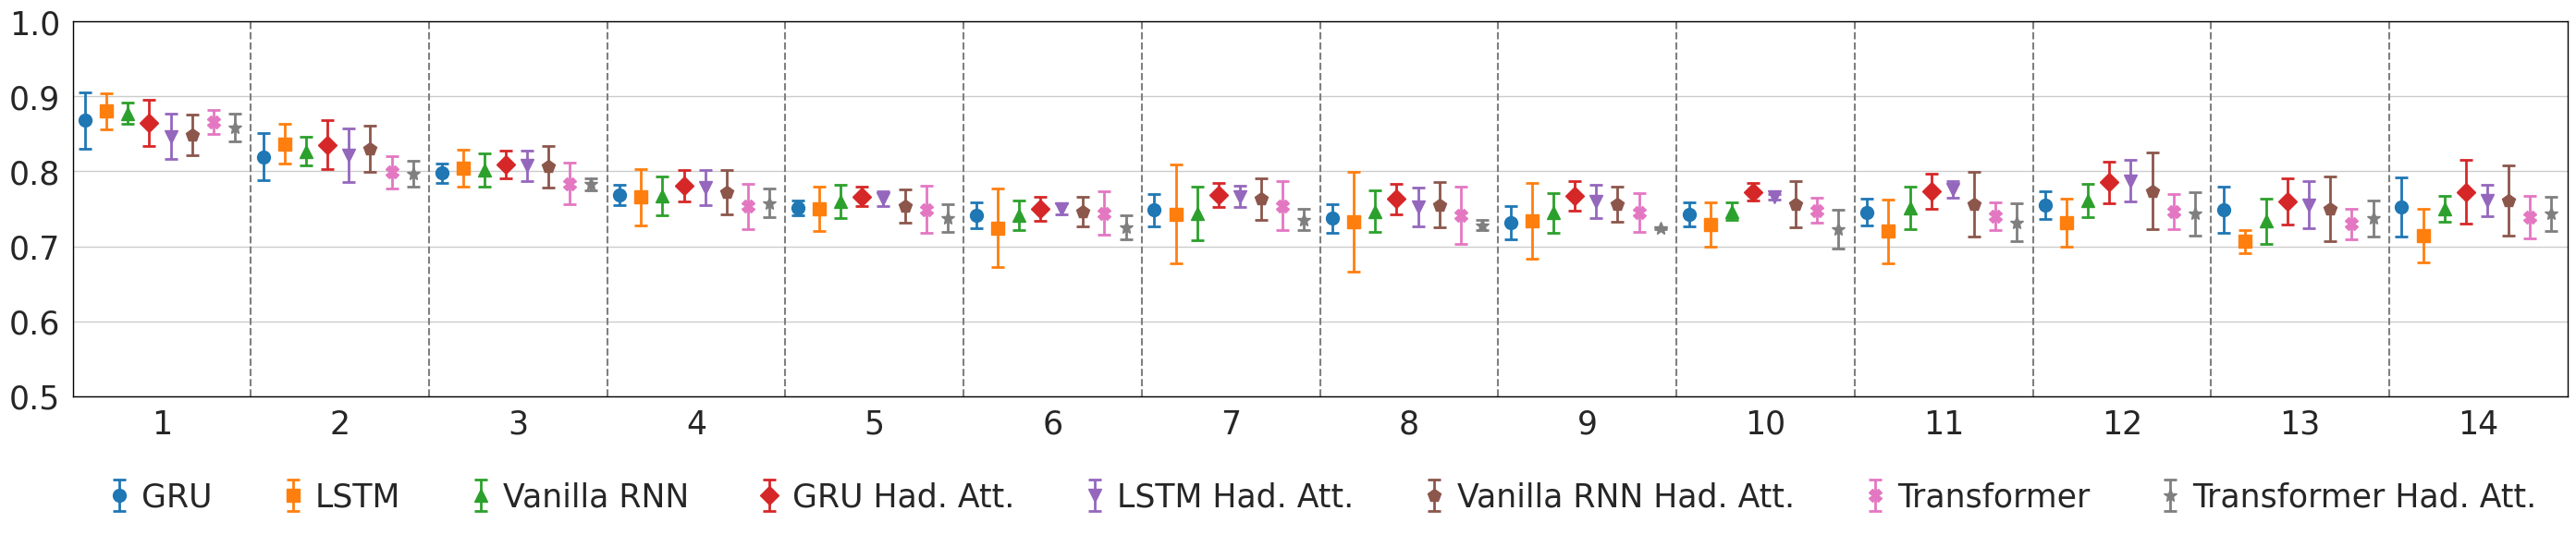

In [15]:
import seaborn as sns
df_gru           = pd.read_csv("POST-HOC/Results_GRU/metrics_GRU.csv")
df_lstm          = pd.read_csv("POST-HOC/Results_LSTM/metrics_LSTM.csv")
df_vanilla       = pd.read_csv("POST-HOC/Results_Vanilla/metrics_Vanilla.csv")
df_gru_had       = pd.read_csv("INTRINSIC/Results_GRU_Had/metrics_GRU_Had.csv")
df_lstm_had      = pd.read_csv("INTRINSIC/Results_LSTM_Had/metrics_LSTM_Had.csv")
df_vanilla_had   = pd.read_csv("INTRINSIC/Results_Vanilla_Had/metrics_Vanilla_Had.csv")
df_trans         = pd.read_csv("POST-HOC/Results_transformer/metrics_transformer.csv")
df_trans_had     = pd.read_csv("INTRINSIC/Results_transformer_Had/metrics_transformer_Had.csv")

methods = [
    'GRU', 'LSTM', 'Vanilla RNN',
    'GRU Had. Att.', 'LSTM Had. Att.', 'Vanilla RNN Had. Att.',
    'Transformer', 'Transformer Had. Att.'
]
n_time_steps = [str(i) for i in range(1, 15)]

def process_df(df, method_name):
    summary = df.groupby('Time Step')['ROC AUC'].agg(['mean', 'std']).reset_index()
    summary['Method'] = method_name
    return summary

gru_df          = process_df(df_gru,         'GRU')
lstm_df         = process_df(df_lstm,        'LSTM')
vanilla_df      = process_df(df_vanilla,     'Vanilla RNN')
gru_had_df      = process_df(df_gru_had,     'GRU Had. Att.')
lstm_had_df     = process_df(df_lstm_had,    'LSTM Had. Att.')
vanilla_had_df  = process_df(df_vanilla_had, 'Vanilla RNN Had. Att.')
trans_df        = process_df(df_trans,       'Transformer')
trans_had_df    = process_df(df_trans_had,   'Transformer Had. Att.')

all_data = pd.concat([
    gru_df, lstm_df, vanilla_df,
    gru_had_df, lstm_had_df, vanilla_had_df,
    trans_df, trans_had_df
], ignore_index=True)

# ——————————————————————————————————————————————
# PLOT
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(28, 5))
ax.xaxis.grid(False)
colors  = sns.color_palette('tab10',    len(methods))
markers = ['o', 's', '^', 'D', 'v', 'p', 'X', '*']
width      = 0.12
shift_right = 0.05

for idx, method in enumerate(methods):
    md = all_data[all_data['Method'] == method]
    x   = np.arange(len(n_time_steps)) + idx * width - (len(methods)*width/2) + shift_right
    y   = md['mean'].values
    yerr= md['std'].values
    ax.errorbar(
        x, y, yerr=yerr,
        label=method,
        marker=markers[idx],
        color=colors[idx],
        linestyle='',
        markersize=10,
        capsize=5,
        elinewidth=2,
        capthick=2
    )

ax.set_xticks(np.arange(len(n_time_steps)))
ax.set_xticklabels(n_time_steps, fontsize=25)
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis='y', labelsize=25)
plt.xlim(-0.5, len(n_time_steps)-0.5)

for xc in range(1, len(n_time_steps)):
    ax.axvline(x=xc-0.5, color='grey', linestyle='--', alpha=1.0)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

plt.tight_layout(pad=1)

ax.legend(
    ncol=len(methods),
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    fontsize=25,           
    frameon=False,
    handlelength=1.0,      
    handletextpad=0.2,     
    columnspacing=2.0,   
    labelspacing=0.1      
)


plt.savefig("./Figures/ROC_AUC_models.pdf",
            bbox_inches='tight', pad_inches=0)
plt.show()


# Sensitivity

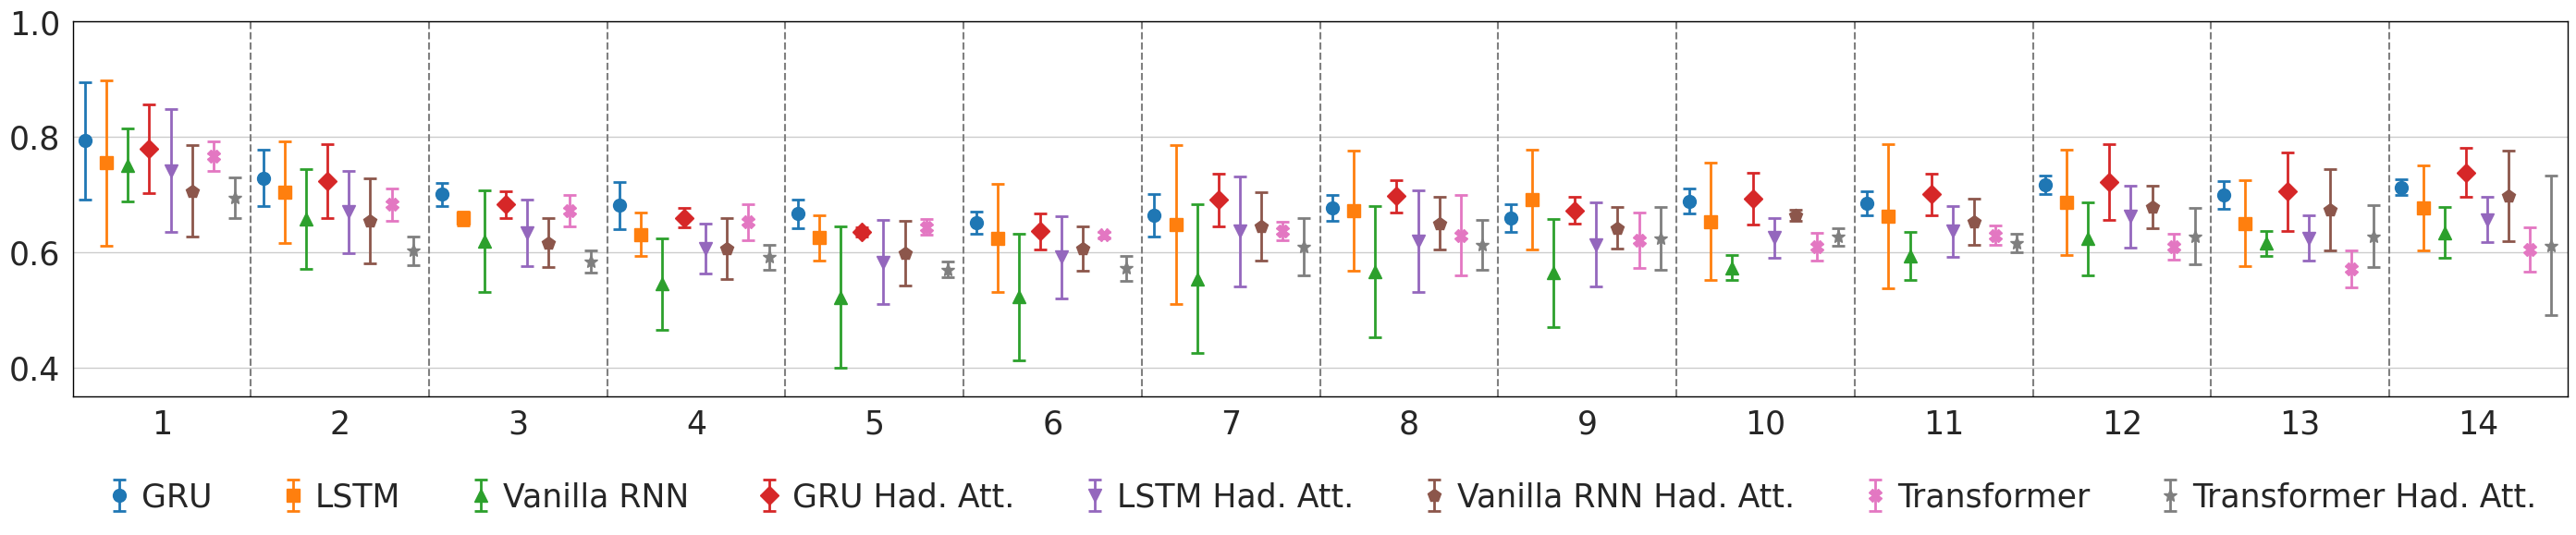

In [16]:
import seaborn as sns
df_gru           = pd.read_csv("POST-HOC/Results_GRU/metrics_GRU.csv")
df_lstm          = pd.read_csv("POST-HOC/Results_LSTM/metrics_LSTM.csv")
df_vanilla       = pd.read_csv("POST-HOC/Results_Vanilla/metrics_Vanilla.csv")
df_gru_had       = pd.read_csv("INTRINSIC/Results_GRU_Had/metrics_GRU_Had.csv")
df_lstm_had      = pd.read_csv("INTRINSIC/Results_LSTM_Had/metrics_LSTM_Had.csv")
df_vanilla_had   = pd.read_csv("INTRINSIC/Results_Vanilla_Had/metrics_Vanilla_Had.csv")
df_trans         = pd.read_csv("POST-HOC/Results_transformer/metrics_transformer.csv")
df_trans_had     = pd.read_csv("INTRINSIC/Results_transformer_Had/metrics_transformer_Had.csv")

# Métodos y pasos temporales
methods = [
    'GRU', 'LSTM', 'Vanilla RNN',
    'GRU Had. Att.', 'LSTM Had. Att.', 'Vanilla RNN Had. Att.',
    'Transformer', 'Transformer Had. Att.'
]
n_time_steps = [str(i) for i in range(1, 15)]

def process_df(df, method_name):
    summary = df.groupby('Time Step')['Recall'].agg(['mean', 'std']).reset_index()
    summary['Method'] = method_name
    return summary

gru_df          = process_df(df_gru,         'GRU')
lstm_df         = process_df(df_lstm,        'LSTM')
vanilla_df      = process_df(df_vanilla,     'Vanilla RNN')
gru_had_df      = process_df(df_gru_had,     'GRU Had. Att.')
lstm_had_df     = process_df(df_lstm_had,    'LSTM Had. Att.')
vanilla_had_df  = process_df(df_vanilla_had, 'Vanilla RNN Had. Att.')
trans_df        = process_df(df_trans,       'Transformer')
trans_had_df    = process_df(df_trans_had,   'Transformer Had. Att.')

all_data = pd.concat([
    gru_df, lstm_df, vanilla_df,
    gru_had_df, lstm_had_df, vanilla_had_df,
    trans_df, trans_had_df
], ignore_index=True)

# ——————————————————————————————————————————————
# PLOT
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(28, 5))
ax.xaxis.grid(False)
colors  = sns.color_palette('tab10',    len(methods))
markers = ['o', 's', '^', 'D', 'v', 'p', 'X', '*']
width      = 0.12
shift_right = 0.05

for idx, method in enumerate(methods):
    md = all_data[all_data['Method'] == method]
    x   = np.arange(len(n_time_steps)) + idx * width - (len(methods)*width/2) + shift_right
    y   = md['mean'].values
    yerr= md['std'].values
    ax.errorbar(
        x, y, yerr=yerr,
        label=method,
        marker=markers[idx],
        color=colors[idx],
        linestyle='',
        markersize=10,
        capsize=5,
        elinewidth=2,
        capthick=2
    )

ax.set_xticks(np.arange(len(n_time_steps)))
ax.set_xticklabels(n_time_steps, fontsize=25)
ax.set_ylim(0.35, 1.0)
ax.tick_params(axis='y', labelsize=25)
plt.xlim(-0.5, len(n_time_steps)-0.5)

for xc in range(1, len(n_time_steps)):
    ax.axvline(x=xc-0.5, color='grey', linestyle='--', alpha=1.0)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

plt.tight_layout(pad=1)

ax.legend(
    ncol=len(methods),
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    fontsize=25,           
    frameon=False,
    handlelength=1.0,      
    handletextpad=0.2,     
    columnspacing=2.0,   
    labelspacing=0.1      
)


plt.savefig("./Figures/Recall_models.pdf",
            bbox_inches='tight', pad_inches=0)
plt.show()


# Specificity

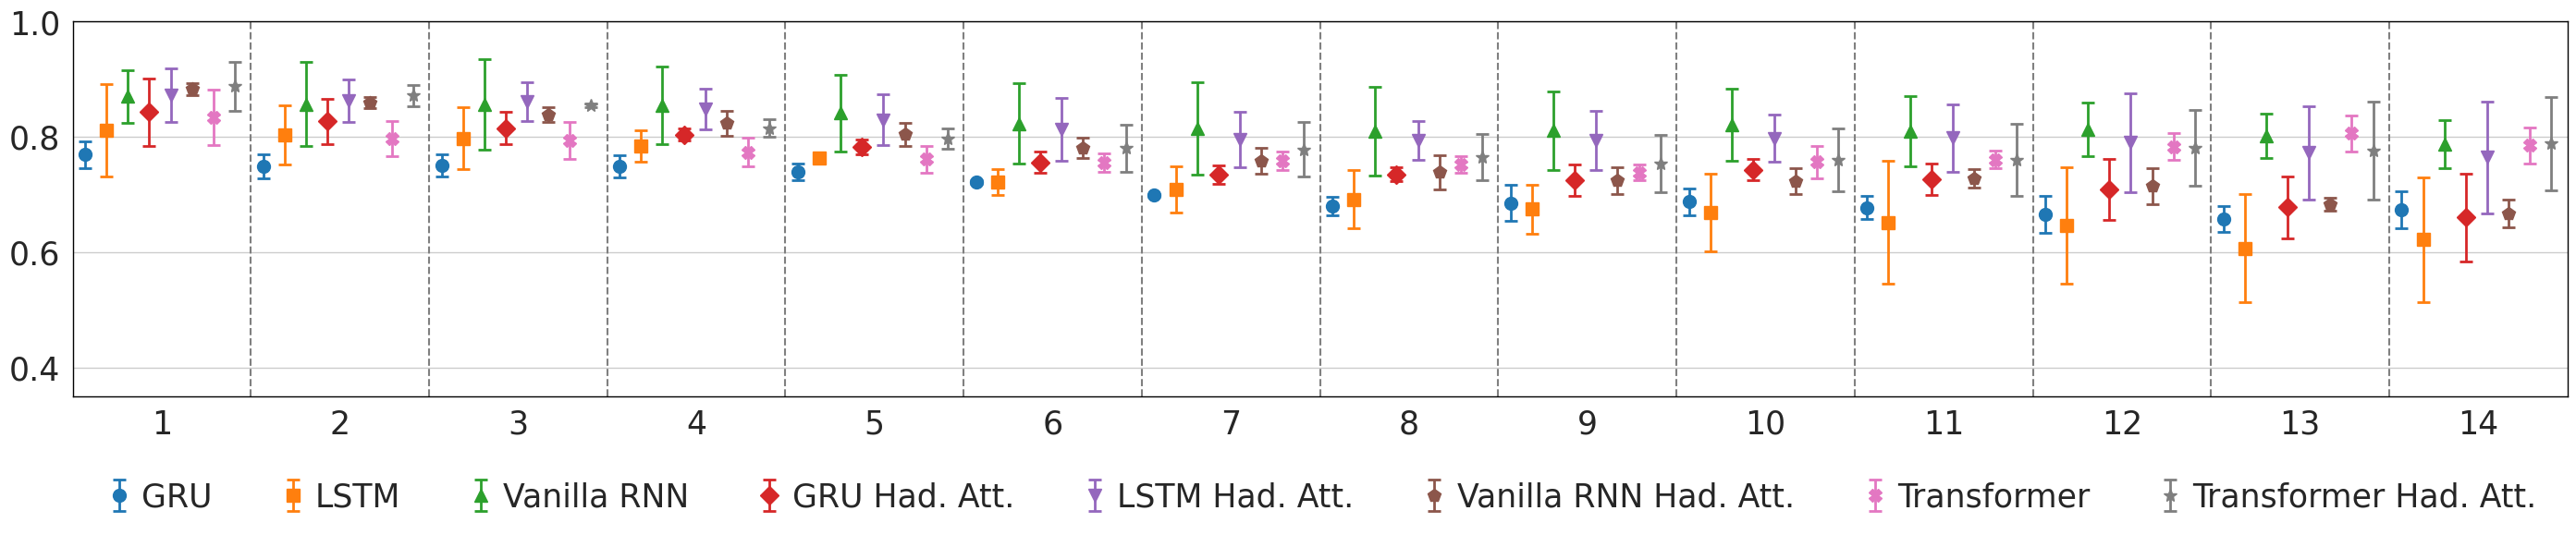

In [17]:
import seaborn as sns
df_gru           = pd.read_csv("POST-HOC/Results_GRU/metrics_GRU.csv")
df_lstm          = pd.read_csv("POST-HOC/Results_LSTM/metrics_LSTM.csv")
df_vanilla       = pd.read_csv("POST-HOC/Results_Vanilla/metrics_Vanilla.csv")
df_gru_had       = pd.read_csv("INTRINSIC/Results_GRU_Had/metrics_GRU_Had.csv")
df_lstm_had      = pd.read_csv("INTRINSIC/Results_LSTM_Had/metrics_LSTM_Had.csv")
df_vanilla_had   = pd.read_csv("INTRINSIC/Results_Vanilla_Had/metrics_Vanilla_Had.csv")
df_trans         = pd.read_csv("POST-HOC/Results_transformer/metrics_transformer.csv")
df_trans_had     = pd.read_csv("INTRINSIC/Results_transformer_Had/metrics_transformer_Had.csv")

methods = [
    'GRU', 'LSTM', 'Vanilla RNN',
    'GRU Had. Att.', 'LSTM Had. Att.', 'Vanilla RNN Had. Att.',
    'Transformer', 'Transformer Had. Att.'
]
n_time_steps = [str(i) for i in range(1, 15)]

def process_df(df, method_name):
    summary = df.groupby('Time Step')['Specificity'].agg(['mean', 'std']).reset_index()
    summary['Method'] = method_name
    return summary

gru_df          = process_df(df_gru,         'GRU')
lstm_df         = process_df(df_lstm,        'LSTM')
vanilla_df      = process_df(df_vanilla,     'Vanilla RNN')
gru_had_df      = process_df(df_gru_had,     'GRU Had. Att.')
lstm_had_df     = process_df(df_lstm_had,    'LSTM Had. Att.')
vanilla_had_df  = process_df(df_vanilla_had, 'Vanilla RNN Had. Att.')
trans_df        = process_df(df_trans,       'Transformer')
trans_had_df    = process_df(df_trans_had,   'Transformer Had. Att.')

all_data = pd.concat([
    gru_df, lstm_df, vanilla_df,
    gru_had_df, lstm_had_df, vanilla_had_df,
    trans_df, trans_had_df
], ignore_index=True)

# ——————————————————————————————————————————————
# PLOT
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(28, 5))

ax.xaxis.grid(False)
colors  = sns.color_palette('tab10',    len(methods))
markers = ['o', 's', '^', 'D', 'v', 'p', 'X', '*']
width      = 0.12
shift_right = 0.05

for idx, method in enumerate(methods):
    md = all_data[all_data['Method'] == method]
    x   = np.arange(len(n_time_steps)) + idx * width - (len(methods)*width/2) + shift_right
    y   = md['mean'].values
    yerr= md['std'].values
    ax.errorbar(
        x, y, yerr=yerr,
        label=method,
        marker=markers[idx],
        color=colors[idx],
        linestyle='',
        markersize=10,
        capsize=5,
        elinewidth=2,
        capthick=2
    )

ax.set_xticks(np.arange(len(n_time_steps)))
ax.set_xticklabels(n_time_steps, fontsize=25)
ax.set_ylim(0.35, 1.0)
ax.tick_params(axis='y', labelsize=25)
plt.xlim(-0.5, len(n_time_steps)-0.5)

for xc in range(1, len(n_time_steps)):
    ax.axvline(x=xc-0.5, color='grey', linestyle='--', alpha=1.0)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

plt.tight_layout(pad=1)

ax.legend(
    ncol=len(methods),
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    fontsize=25,           
    frameon=False,
    handlelength=1.0,      
    handletextpad=0.2,     
    columnspacing=2.0,   
    labelspacing=0.1      
)

plt.savefig("./Figures/Specificity_models.pdf",
            bbox_inches='tight', pad_inches=0)
plt.show()